# Activation Functions in Deep Learning

Bu notebook'ta derin öğrenmede kullanılan temel aktivasyon fonksiyonlarını detaylı olarak inceleyeceğiz:

1. **Sigmoid** - Binary classification ve gating
2. **Softmax** - Multi-class classification
3. **ReLU** - En temel aktivasyon
4. **GELU** - Transformer'larda kullanılan
5. **SiLU (Swish)** - Google'ın keşfi
6. **SwiGLU** - Modern LLM'lerde kullanılan

---

## 1. Sigmoid (Logistic)

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Sigmoid fonksiyonu
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

### Sigmoid Formülü

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

**Özellikler:**
- Çıktı aralığı: (0, 1)
- Sigmoidoidal (S-şeklinde)
- Her değer bağımsız olarak işlenir

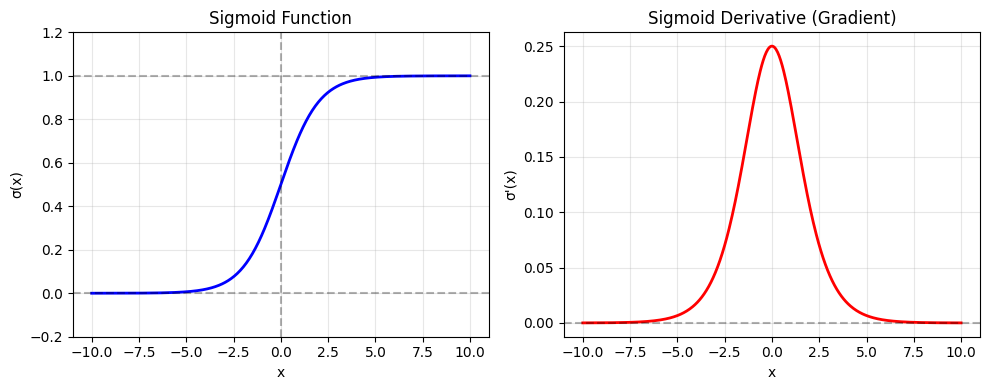

In [3]:
# Grafik
x = torch.linspace(-10, 10, 500)
y = sigmoid(x)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), y.numpy(), 'b-', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.ylim(-0.2, 1.2)

# Türev (gradient)
y_grad = sigmoid(x) * (1 - sigmoid(x))

plt.subplot(1, 2, 2)
plt.plot(x.numpy(), y_grad.numpy(), 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel("σ'(x)")
plt.title('Sigmoid Derivative (Gradient)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Sigmoid Ne Zaman Kullanılır?

```python
# Binary classification'da son katman
output = torch.sigmoid(logits)  # 0-1 arası olasılık

# Gate mekanizmalarında (ne kadar bilgi geçsin?)
gate = torch.sigmoid(x)  # 0-1 arası ağırlık
filtered = gate * value
```

## 2. Softmax

In [4]:
# Softmax fonksiyonu
def softmax(x, dim=-1):
    exp_x = torch.exp(x - torch.max(x, dim=dim, keepdim=True)[0])
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

### Softmax Formülü

$$ \text{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}} $$

**Özellikler:**
- Çıktı aralığı: (0, 1)
- **Toplam = 1** (olasılık dağılımı)
- Tüm değerler birbirine bağımlı
- En büyük değer daha da büyük görünür (winner-takes-all)

Logits: [2.  1.  0.1]
Softmax: [0.6590012 0.242433  0.0985659]
Toplam: 1.0000001192092896


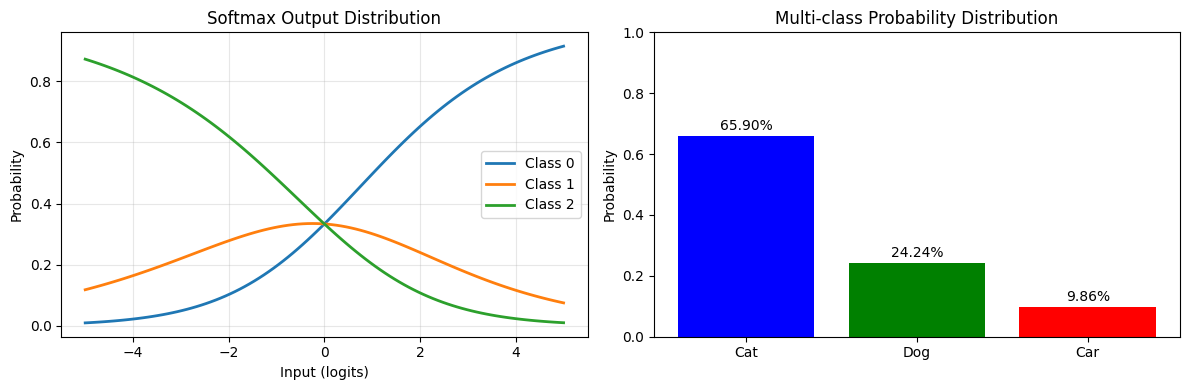

In [5]:
# Örnek: 3 sınıf için softmax
logits = torch.tensor([2.0, 1.0, 0.1])
probs = softmax(logits)

print("Logits:", logits.numpy())
print("Softmax:", probs.numpy())
print("Toplam:", probs.sum().item())

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Farklı logits değerleri
test_logits = torch.linspace(-5, 5, 100)
test_logits_3 = torch.stack([test_logits, test_logits*0.5, test_logits*0.1], dim=1)
test_softmax = softmax(test_logits_3, dim=1)

axes[0].plot(test_logits.numpy(), test_softmax[:, 0].numpy(), label='Class 0', linewidth=2)
axes[0].plot(test_logits.numpy(), test_softmax[:, 1].numpy(), label='Class 1', linewidth=2)
axes[0].plot(test_logits.numpy(), test_softmax[:, 2].numpy(), label='Class 2', linewidth=2)
axes[0].set_xlabel('Input (logits)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Softmax Output Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart
classes = ['Cat', 'Dog', 'Car']
axes[1].bar(classes, probs.numpy(), color=['blue', 'green', 'red'])
axes[1].set_ylabel('Probability')
axes[1].set_title('Multi-class Probability Distribution')
axes[1].set_ylim(0, 1)
for i, v in enumerate(probs.numpy()):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

### Softmax vs Sigmoid Farkı

| Özellik | Sigmoid | Softmax |
|---------|---------|---------|
| Çıktı | (0, 1) tek başına | (0, 1) toplam=1 |
| Bağımsızlık | Her değer bağımsız | Tüm değerler bağımlı |
| Kullanım | Binary, gating | Multi-class |

```python
# Binary: Sigmoid yeterli
is_spam = sigmoid(logit)  # 0.87 → %87 spam

# Multi-class: Softmax gerekli
probs = softmax(logits)  # [0.65, 0.25, 0.10] → toplam = 1
```

## 3. ReLU (Rectified Linear Unit)

In [6]:
# ReLU fonksiyonu
def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

### ReLU Formülü

$$ \text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{eğer } x > 0 \\ 0 & \text{eğer } x \leq 0 \end{cases} $$

**Özellikler:**
- Hesaplaması çok hızlı
- Sparse activation (bazı nöronlar 0)
- Vanishing gradient problemi yok

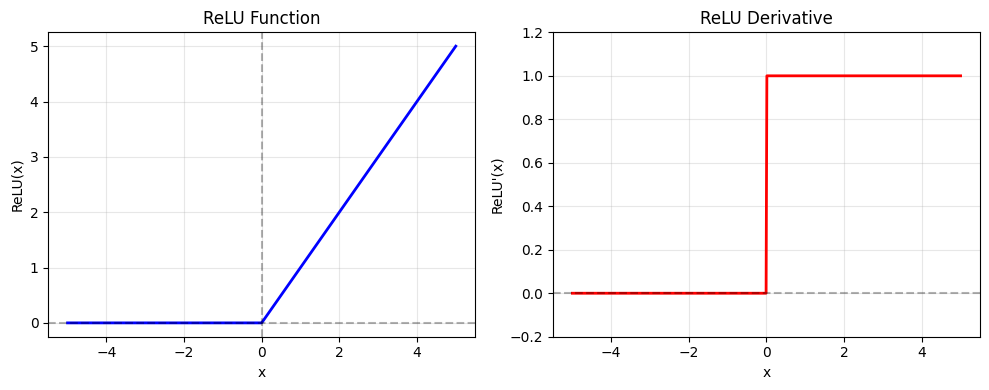

In [7]:
x = torch.linspace(-5, 5, 500)
y = relu(x)
y_grad = (x > 0).float()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), y.numpy(), 'b-', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.title('ReLU Function')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x.numpy(), y_grad.numpy(), 'r-', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel("ReLU'(x)")
plt.title('ReLU Derivative')
plt.grid(True, alpha=0.3)
plt.ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

### Dying ReLU Problem

ReLU'nun dezavantajı: Negatif değerler tamamen 0'a sabitlenir ve bir daha asla "hayata dönemez".

```python
# Problem: Nöron sıfırda "ölmüş"
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
relu(x)  # [0, 0, 0, 1, 2] → İlk 3 nöron öldü!
```

## 4. GELU (Gaussian Error Linear Unit)

In [8]:
# GELU fonksiyonu (approximation)
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

### GELU Formülü

Tam formül: $GELU(x) = x \cdot \Phi(x)$ (Φ = standard normal CDF)

Pratikte kullanılan approximation:

$$ GELU(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot (x + 0.044715 \cdot x^3)\right]\right) $$

**Özellikler:**
- Smooth (sürekli türevlenebilir)
- Negatif bölgede küçük değerler geçirir (GELU(-2) ≈ -0.1)
- ReLU'nun yumuşak versiyonu

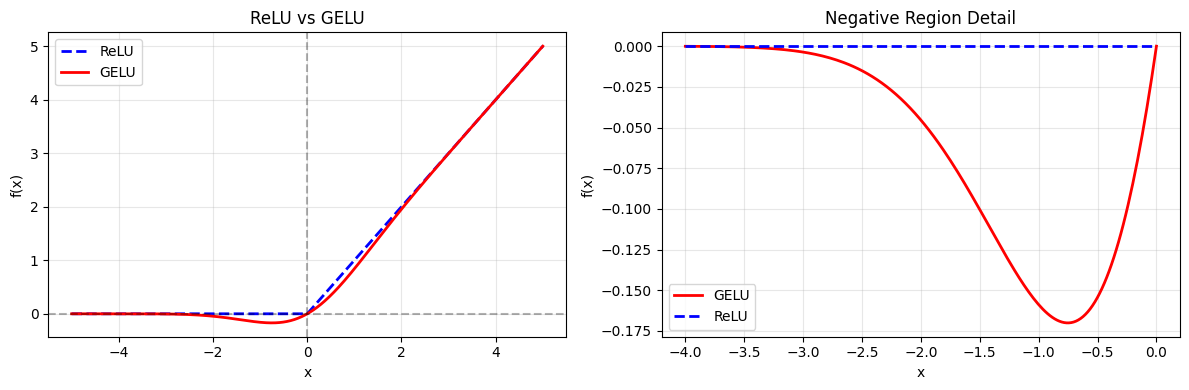

ReLU(-2) = 0.0
GELU(-2) = -0.04540228843688965
GELU negative bölgede küçük değerler geçiriyor!


In [9]:
gelu = GELU()
x = torch.linspace(-5, 5, 500)
y_gelu = gelu(x)
y_relu = relu(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), y_relu.numpy(), 'b--', linewidth=2, label='ReLU')
plt.plot(x.numpy(), y_gelu.numpy(), 'r-', linewidth=2, label='GELU')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('ReLU vs GELU')
plt.legend()
plt.grid(True, alpha=0.3)

# Negatif bölge detayı
plt.subplot(1, 2, 2)
x_neg = torch.linspace(-4, 0, 200)
plt.plot(x_neg.numpy(), gelu(x_neg).numpy(), 'r-', linewidth=2, label='GELU')
plt.plot(x_neg.numpy(), relu(x_neg).numpy(), 'b--', linewidth=2, label='ReLU')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Negative Region Detail')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ReLU(-2) =", relu(torch.tensor(-2.0)).item())
print("GELU(-2) =", gelu(torch.tensor(-2.0)).item())
print("GELU negative bölgede küçük değerler geçiriyor!")

## 5. SiLU (Swish-1) / Swish

In [10]:
# SiLU (Swish) fonksiyonu
def silu(x):
    return x * torch.sigmoid(x)

### SiLU Formülü

$$ \text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}} $$

**Özellikler:**
- "Self-gated" (kendi değeriyle çarpılır)
- Negatif bölgede daha geniş aralık
- 2017'de Google tarafından keşfedildi
- MobileNetV3'te kullanıldı

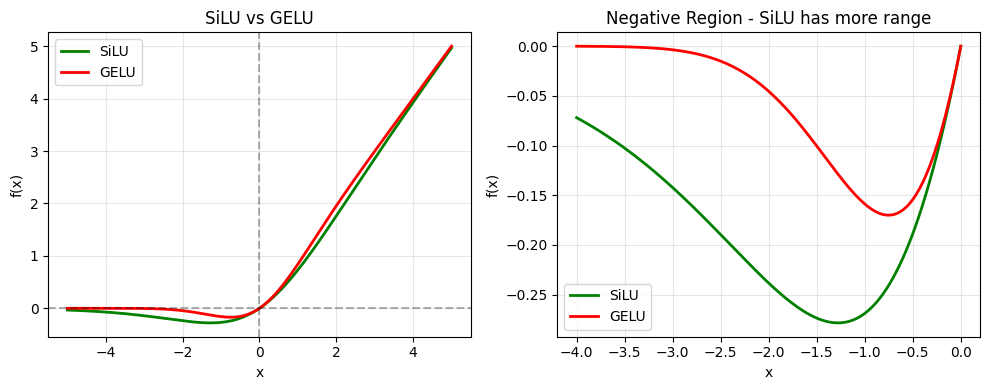


Karşılaştırma:
SiLU(-2) = -0.23840583860874176
GELU(-2) = -0.04540228843688965
SiLU daha geniş negatif aralık geçiriyor!


In [11]:
x = torch.linspace(-5, 5, 500)
y_silu = silu(x)
y_gelu = GELU()(x)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), y_silu.numpy(), 'g-', linewidth=2, label='SiLU')
plt.plot(x.numpy(), y_gelu.numpy(), 'r-', linewidth=2, label='GELU')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('SiLU vs GELU')
plt.legend()
plt.grid(True, alpha=0.3)

# Negatif bölge detayı
plt.subplot(1, 2, 2)
x_neg = torch.linspace(-4, 0, 200)
plt.plot(x_neg.numpy(), silu(x_neg).numpy(), 'g-', linewidth=2, label='SiLU')
plt.plot(x_neg.numpy(), GELU()(x_neg).numpy(), 'r-', linewidth=2, label='GELU')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Negative Region - SiLU has more range')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKarşılaştırma:")
print("SiLU(-2) =", silu(torch.tensor(-2.0)).item())
print("GELU(-2) =", GELU()(torch.tensor(-2.0)).item())
print("SiLU daha geniş negatif aralık geçiriyor!")

## 6. SwiGLU (Swish-Gated Linear Unit)

In [13]:
# SwiGLU (FeedForward modülü olarak)
class SwiGLU(nn.Module):
    """
    SwiGLU: 3 linear layer + SiLU gating
    Used in LLaMA, Mixtral, Mistral
    """
    def __init__(self, embed_dim):
        super().__init__()
        hidden_dim = 4 * embed_dim
        self.w1 = nn.Linear(embed_dim, hidden_dim)  # gate
        self.v = nn.Linear(embed_dim, hidden_dim)  # value
        self.w3 = nn.Linear(hidden_dim, embed_dim) # output
    
    def forward(self, x):
        return self.w3(nn.functional.silu(self.w1(x)) * self.v(x))

### SwiGLU Yapısı

```
x
├──→ Linear(w1) → SiLU ──┐
│                        ├─→ * ──→ Linear(w3) → output
└──→ Linear(v)  ─────────┘
```

**Özellikler:**
- 3 linear layer gerektirir
- Gating mekanizması ile hangi bilgilerin geçeceğini öğrenir
- LLaMA, Mixtral, Mistral gibi modern LLM'lerde kullanılır

In [14]:
# SwiGLU test
swiglu = SwiGLU(embed_dim=768)

# Rastgele input
x = torch.randn(2, 4, 768)  # batch=2, seq=4, embed=768
output = swiglu(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

# Parametre sayısı
total_params = sum(p.numel() for p in swiglu.parameters())
print(f"SwiGLU parameters: {total_params:,}")

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
SwiGLU parameters: 7,084,800


## Tüm Aktivasyon Fonksiyonlarının Karşılaştırması

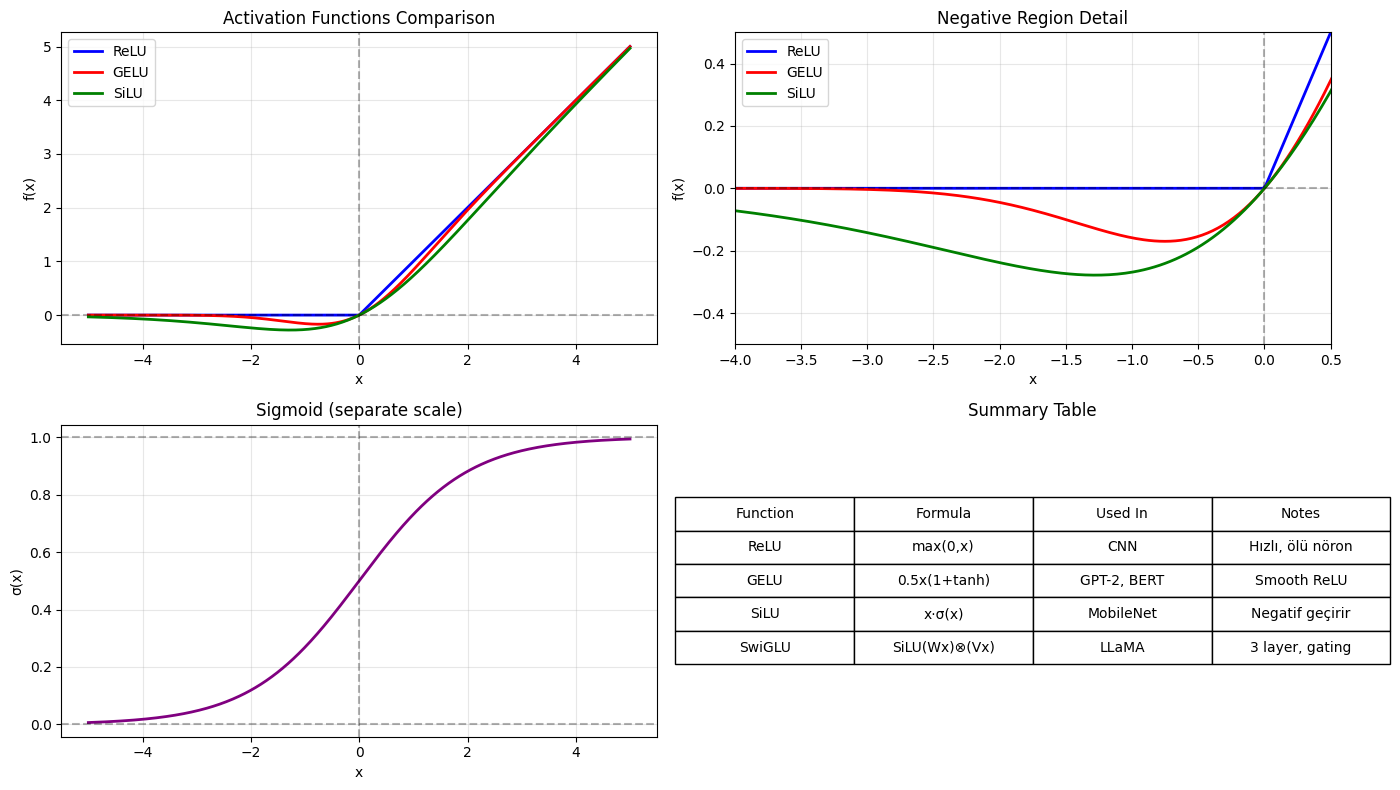

In [15]:
x = torch.linspace(-5, 5, 500)

# Tüm fonksiyonlar
y_sigmoid = torch.sigmoid(x)
y_relu = relu(x)
y_gelu = GELU()(x)
y_silu = silu(x)

plt.figure(figsize=(14, 8))

# Ana grafik
plt.subplot(2, 2, 1)
plt.plot(x.numpy(), y_relu.numpy(), 'b-', linewidth=2, label='ReLU')
plt.plot(x.numpy(), y_gelu.numpy(), 'r-', linewidth=2, label='GELU')
plt.plot(x.numpy(), y_silu.numpy(), 'g-', linewidth=2, label='SiLU')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Activation Functions Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Negatif bölge
plt.subplot(2, 2, 2)
plt.plot(x.numpy(), y_relu.numpy(), 'b-', linewidth=2, label='ReLU')
plt.plot(x.numpy(), y_gelu.numpy(), 'r-', linewidth=2, label='GELU')
plt.plot(x.numpy(), y_silu.numpy(), 'g-', linewidth=2, label='SiLU')
plt.xlim(-4, 0.5)
plt.ylim(-0.5, 0.5)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Negative Region Detail')
plt.legend()
plt.grid(True, alpha=0.3)

# Sigmoid (ayrı scale)
plt.subplot(2, 2, 3)
plt.plot(x.numpy(), y_sigmoid.numpy(), 'purple', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.title('Sigmoid (separate scale)')
plt.grid(True, alpha=0.3)

# Özet tablo
plt.subplot(2, 2, 4)
plt.axis('off')

table_data = [
    ['ReLU', 'max(0,x)', 'CNN', 'Hızlı, ölü nöron'],
    ['GELU', '0.5x(1+tanh)', 'GPT-2, BERT', 'Smooth ReLU'],
    ['SiLU', 'x·σ(x)', 'MobileNet', 'Negatif geçirir'],
    ['SwiGLU', 'SiLU(Wx)⊗(Vx)', 'LLaMA', '3 layer, gating'],
]

table = plt.table(cellText=table_data,
                  colLabels=['Function', 'Formula', 'Used In', 'Notes'],
                  loc='center',
                  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
plt.title('Summary Table')

plt.tight_layout()
plt.show()

## Özet: Hangisi Ne Zaman Kullanılır?

In [16]:
# Pratik karar rehberi
decision_guide = """
┌─────────────────────────────────────────────────────────────────┐
│                    AKTİVASYON FONKSİYON REHBERİ                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│ 🟦 BİNARY CLASSIFICATION                                       │
│    → Sigmoid (son katmanda)                                    │
│                                                                 │
│ 🟩 MULTİ-CLASS CLASSIFICATION                                  │
│    → Softmax (son katmanda)                                    │
│                                                                 │
│ 🟨 GATE MECHANISM                                              │
│    → Sigmoid (ne kadar bilgi geçsin?)                          │
│                                                                 │
│ 🟧 CNN / GELENEKSEL DNN                                        │
│    → ReLU (hızlı, basit)                                      │
│                                                                 │
│ ⬛ TRANSFORMER (Original GPT, BERT)                            │
│    → GELU                                                      │
│                                                                 │
│ ⬜ MODERN LLMs (LLaMA, Mixtral, Mistral)                       │
│    → SwiGLU (FeedForward'de)                                  │
│                                                                 │
│ 🟪 MobileNet / EfficientNet                                   │
│    → SiLU (Swish)                                              │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
"""
print(decision_guide)


┌─────────────────────────────────────────────────────────────────┐
│                    AKTİVASYON FONKSİYON REHBERİ                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│ 🟦 BİNARY CLASSIFICATION                                       │
│    → Sigmoid (son katmanda)                                    │
│                                                                 │
│ 🟩 MULTİ-CLASS CLASSIFICATION                                  │
│    → Softmax (son katmanda)                                    │
│                                                                 │
│ 🟨 GATE MECHANISM                                              │
│    → Sigmoid (ne kadar bilgi geçsin?)                          │
│                                                                 │
│ 🟧 CNN / GELENEKSEL DNN                                        │
│    → ReLU (hızlı, basit)                                

## Sonuç

1. **Sigmoid**: Binary output, gating için
2. **Softmax**: Multi-class için zorunlu
3. **ReLU**: Hızlı ama "ölü nöron" riski
4. **GELU**: Transformer standardı (GPT-2, BERT)
5. **SiLU**: GELU'ya benzer ama daha açık
6. **SwiGLU**: En güçlü, modern LLM'lerde

---